<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/practica22_267370.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.


```python
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```


2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


In [1]:
# =========================
# 1. IMPORTACIONES
# =========================
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# 2. CARGAR DATASET
# =========================
wine = load_wine()
X = wine.data # Son las variables (features)
y = wine.target # Las clases (tipos de vinos)

# Convertimos a DataFrame para trabajar más cómodo
df = pd.DataFrame(X, columns=wine.feature_names)

# =========================
# 3. SELECCIONAR FEATURE
# =========================
alcohol = df['alcohol']



In [2]:
# =========================
# 4. PRUEBA DE NORMALIDAD ORIGINAL
# =========================
# Se aplica prueba de normalidad para ver si los datos siguen una distribución
# normal (valores centrados en un promedio, simétricos, la mayoría de datos en el centro)
# esto porque muchos modelos asumen que los datos son normales (regresión lineal, intervalos de confianza)

# shapiro -> evalúa si los datos se parecen a una distribución normal
stat_original, p_original = shapiro(alcohol)

print("Shapiro Test (Original)")
print("Estadístico:", stat_original) # que tan cerca estamos de una normal
print("p-valor:", p_original) # -> valor p, el que realmente importa ¿Qué tan probable es que los datos sean normales?

# > 0.05 -> Los datos parecen normales
# < 0.05 -> Datos NO son normales



Shapiro Test (Original)
Estadístico: 0.9818041416927711
p-valor: 0.020047981728854945


In [3]:
# =========================
# 5. NORMALIZACIÓN MIN-MAX
# =========================
# Transforma todos los datos de 0's a 1's
# Alcohol: [12, 13, 14]
# [0, 0.5, 1]
scaler = MinMaxScaler()
alcohol_scaled = scaler.fit_transform(alcohol.values.reshape(-1, 1))
# De lo anterior:
# MinMaxScaler()	-> Prepara el escalador
# fit_transform()	-> Aprende min/max y escala
# reshape(-1,1)	  -> Ajusta formato para sklearn
# flatten()	      -> Regresa a 1 dimensión
# pd.Series()	    -> Vuelve a pandas

# Convertimos a serie para facilitar
alcohol_scaled = pd.Series(alcohol_scaled.flatten())

# =========================
# 6. PRUEBA DE NORMALIDAD NORMALIZADO
# =========================
stat_scaled, p_scaled = shapiro(alcohol_scaled)

print("\nShapiro Test (Normalizado)")
print("Estadístico:", stat_scaled)
print("p-valor:", p_scaled)




Shapiro Test (Normalizado)
Estadístico: 0.9818041416927711
p-valor: 0.020047981728854858


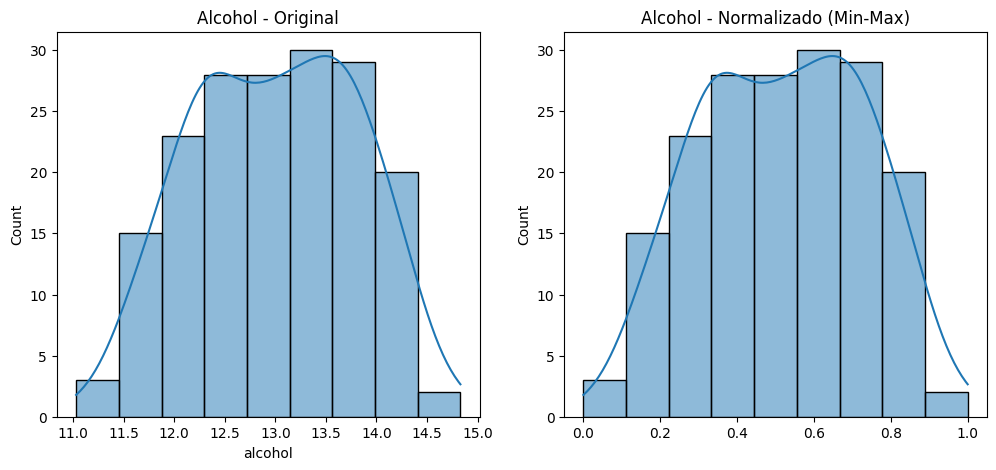

In [4]:
# =========================
# 7. GRÁFICAS
# =========================
plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sns.histplot(alcohol, kde=True)
plt.title("Alcohol - Original")

# Normalizado
plt.subplot(1,2,2)
sns.histplot(alcohol_scaled, kde=True)
plt.title("Alcohol - Normalizado (Min-Max)")

plt.show()

## ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
La normalización Min-Max no alteró la forma de la distribución de los datos, únicamente transformó los valores a un rango entre 0 y 1. Esto se observa en que la estructura de los datos se mantiene, sin cambios en su comportamiento estadístico.

## ¿Qué interpretas del p-valor antes y después de la normalización?

El p-valor antes y después de la normalización es prácticamente idéntico (~0.020), lo cual indica que la transformación no afectó la normalidad de los datos. Dado que el p-valor es menor a 0.05, se rechaza la hipótesis nula de normalidad en ambos casos, concluyendo que la variable no sigue una distribución normal.

# Ejercicio 2: Normalización Z-Score

Instrucciones:
1. Cargar el dataset wine de sklearn.
2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4. Aplicar la normalización Z-Score a los datos seleccionados.
5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7. Responder las preguntas siguientes.

Preguntas:
1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



La normalización con Z-Score (estandarización) se usa para reposicionar los datos con respecto a la media; Transforma los datos para tener
* Media = 0
* Desviación estándar = 1

In [5]:
# =========================
# 1. IMPORTACIONES / SELECCIÓN DE VARIABLE
# =========================
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

malic_acid = df['malic_acid']

In [6]:
# =========================
# 2. PRUEBA DE NORMALIDAD ORIGINAL
# =========================
from scipy.stats import shapiro

stat_orig, p_orig = shapiro(malic_acid)

print("Original:")
print("p-valor:", p_orig)

Original:
p-valor: 2.945800703600761e-10


In [9]:
# =========================
# 3. NORMALIZACIÓN Z-SCORE
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

malic_scaled = scaler.fit_transform(malic_acid.values.reshape(-1,1))
malic_scaled = pd.Series(malic_scaled.flatten())

In [10]:
# =========================
# 4. PRUEBA DE NORMALIDAD DESPUÉS
# =========================

stat_scaled, p_scaled = shapiro(malic_scaled)

print("\nEscalado:")
print("p-valor:", p_scaled)


Escalado:
p-valor: 2.9458007036005247e-10


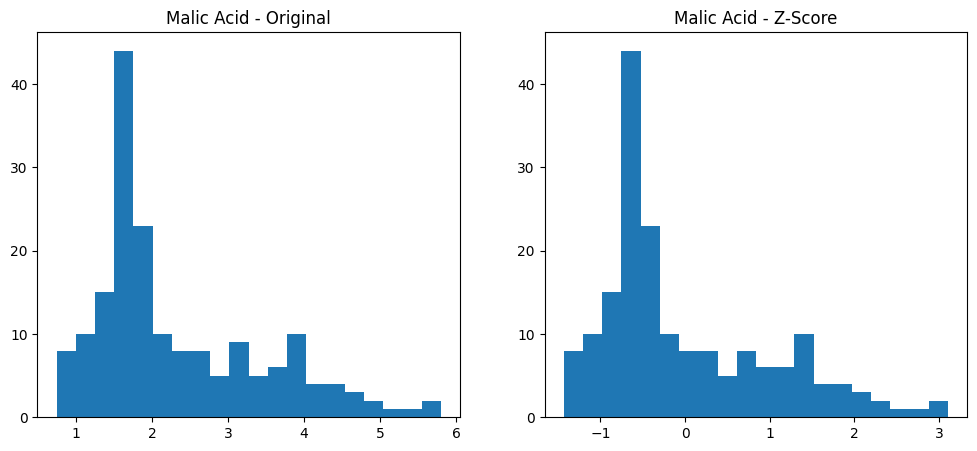

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
plt.hist(malic_acid, bins=20)
plt.title("Malic Acid - Original")

# Escalado
plt.subplot(1,2,2)
plt.hist(malic_scaled, bins=20)
plt.title("Malic Acid - Z-Score")

plt.show()

## ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?

La normalización Z-Score no modifica la forma de la distribución de los datos, sino que los centra alrededor de cero y los escala en términos de desviaciones estándar. Esto se evidencia en que la distribución mantiene su estructura original, aunque ahora está expresada en una nueva escala.

## ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?

La normalización Z-Score permite comparar valores en función de su distancia respecto a la media, facilitando la detección de valores atípicos (outliers) y mejorando el rendimiento de modelos sensibles a la escala. Sin embargo, no corrige problemas de normalidad, como se observa en el p-valor, que permanece prácticamente igual antes y después de la transformación.

#Ejercicio 3: Transformación Logarítmica
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy:
    - Número de observaciones = 1000;
    - Valor de semilla = `np.random.seed(42)`
    - Distribucion exponencial: `np.random.exponential(scale=2, size=1000)`
2. Aplicar una transformación logarítmica (np.log) a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


### ¿Qué se supone que hace la transformación logaritmica?

Comprimir valores grandes e intenta eliminar el sesgo a la derecha, el propósito es acercar la distribución a algo más parecido a la normal.

Se usa con distribuciones muy sesgadas, de tipo exponenciales o con cola larga hacia la derecha


In [13]:
# =========================
# 1. CARGAR DATASET
# =========================

import numpy as np

np.random.seed(42)
data = np.random.exponential(scale=2, size=1000)

In [14]:
# =========================
# 2. APLICAR EL LOG
# =========================
log_data = np.log(data)

In [15]:
# =========================
# 3. PRUEBA DE NORMALIDAD
# =========================
from scipy.stats import shapiro

stat_orig, p_orig = shapiro(data)
stat_log, p_log = shapiro(log_data)

print("Original p-valor:", p_orig)
print("Log p-valor:", p_log)

Original p-valor: 1.094865579608503e-31
Log p-valor: 1.3218330609682656e-16


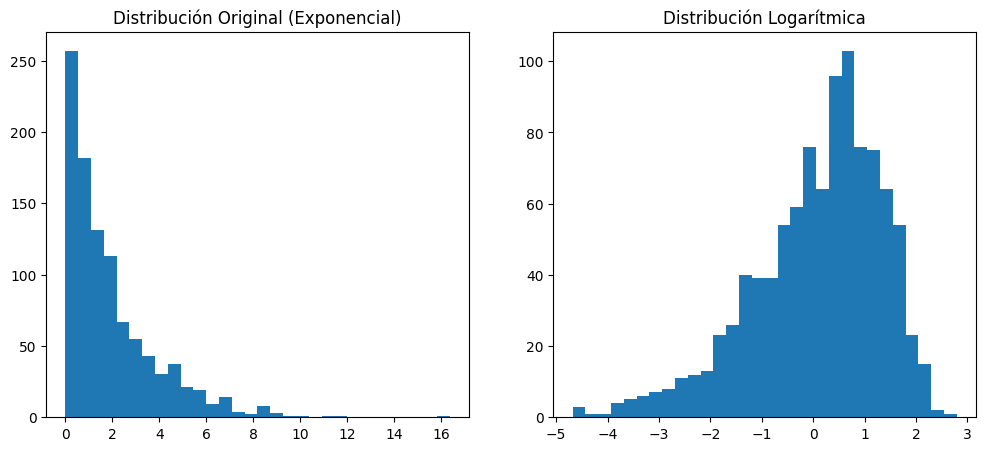

In [16]:
# =========================
# 4. GRÁFICAS
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
plt.hist(data, bins=30)
plt.title("Distribución Original (Exponencial)")

# Log
plt.subplot(1,2,2)
plt.hist(log_data, bins=30)
plt.title("Distribución Logarítmica")

plt.show()

## ¿Cómo afectó la transformación logarítmica a la distribución de los datos?

La transformación logarítmica redujo significativamente la asimetría de la distribución original, comprimiendo los valores grandes y haciendo que la distribución sea más simétrica. Esto permitió que los datos se aproximaran más a una forma similar a la distribución normal.

## ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?

El p-valor aumentó considerablemente después de la transformación logarítmica (de 1.09e-31 a 1.32e-16), lo que indica que los datos se acercaron a una distribución normal. Sin embargo, dado que el p-valor sigue siendo menor a 0.05, se concluye que los datos aún no siguen una distribución normal.

#Ejercicio 4: Transformación Raíz Cuadrada
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Número de observaciones: 1000
    - Semilla = `np.random.seed(42)``
    - Distribución Poisson: `np.random.poisson(lam=5, size=1000)`
2. Aplicar una transformación de raíz cuadrada a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


### ¿Para qué sirve la transformación de raíz cuadrada?

Reduce la dispersión y comprime los valores grandes (pero menos que log) pero mantiene la estructura original.

Se usa en tipos de datos de conteos, frecuencias y datos discretos.

In [17]:
# =========================
# 1. CARGAR DATASET
# =========================

import numpy as np

np.random.seed(42)
data = np.random.poisson(lam=5, size=1000)

In [18]:
# =========================
# 2. Aplicar raíz cuadrada
# =========================

sqrt_data = np.sqrt(data)

In [19]:
# =========================
# 3. APLICAR LA PRUEBA DE NORMALIDAD
# =========================

from scipy.stats import shapiro

stat_orig, p_orig = shapiro(data)
stat_sqrt, p_sqrt = shapiro(sqrt_data)

print("Original p-valor:", p_orig)
print("Raíz cuadrada p-valor:", p_sqrt)

Original p-valor: 6.523300091890513e-13
Raíz cuadrada p-valor: 5.668642183851904e-14


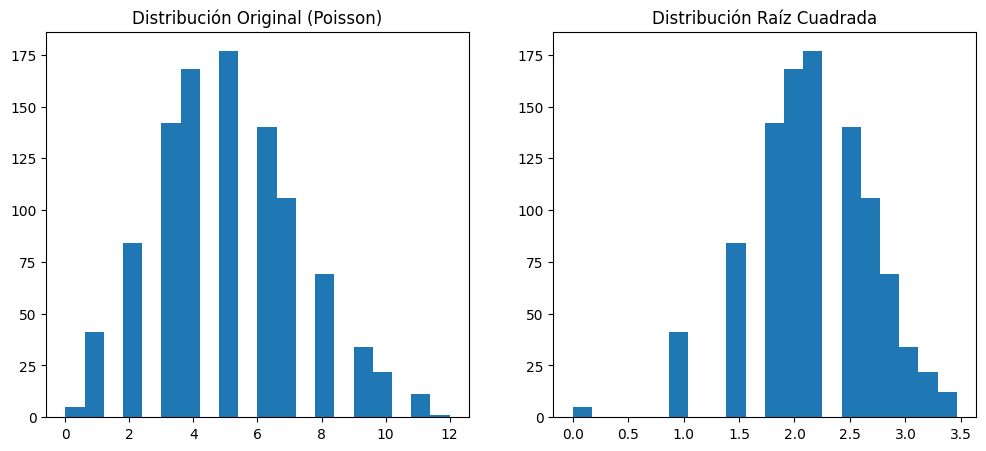

In [20]:
# =========================
# 4. GRÁFICAS
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
plt.hist(data, bins=20)
plt.title("Distribución Original (Poisson)")

# Transformado
plt.subplot(1,2,2)
plt.hist(sqrt_data, bins=20)
plt.title("Distribución Raíz Cuadrada")

plt.show()

### ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?

La transformación de raíz cuadrada redujo ligeramente la dispersión de los datos, pero no logró mejorar la normalidad de la distribución. De hecho, el p-valor disminuyó, lo que indica que la distribución transformada se alejó ligeramente de la normalidad según la prueba de Shapiro.

### ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?

La raíz cuadrada reduce la magnitud de los valores más grandes, disminuyendo el impacto de valores extremos. Sin embargo, esta reducción es moderada y no siempre suficiente para mejorar significativamente la forma de la distribución.

#Ejercicio 5: Transformación Box-Cox
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Numero de observaciones: 1000
    - Semilla: `np.random.seed(42)``
    - Distribución log-normal: `np.random.lognormal(mean=1, sigma=0.8, size=1000)`
2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


### ¿Para qué sirve Box-Cox?

Es una transformación que busca automáticamente la mejor forma de hacer tus datos más normales.

In [25]:
# =========================
# 1. CARGAR DATASET
# =========================

import numpy as np

np.random.seed(42)
data = np.random.lognormal(mean=1, sigma=0.8, size=1000)

In [22]:
# =========================
# 2. APLICAR BOX-COX
# =========================
from scipy.stats import boxcox

data_boxcox, lambda_opt = boxcox(data)

# data_boxcox → datos transformados
# lambda_opt → el parámetro óptimo ⭐

In [23]:
# =========================
# 3. PRUEBA DE NORMALIDAD
# =========================

from scipy.stats import shapiro

stat_orig, p_orig = shapiro(data)
stat_box, p_box = shapiro(data_boxcox)

print("Original p-valor:", p_orig)
print("Box-Cox p-valor:", p_box)
print("Lambda:", lambda_opt)

Original p-valor: 6.966496130945429e-41
Box-Cox p-valor: 0.9891215954703348
Lambda: -0.04889276450171702


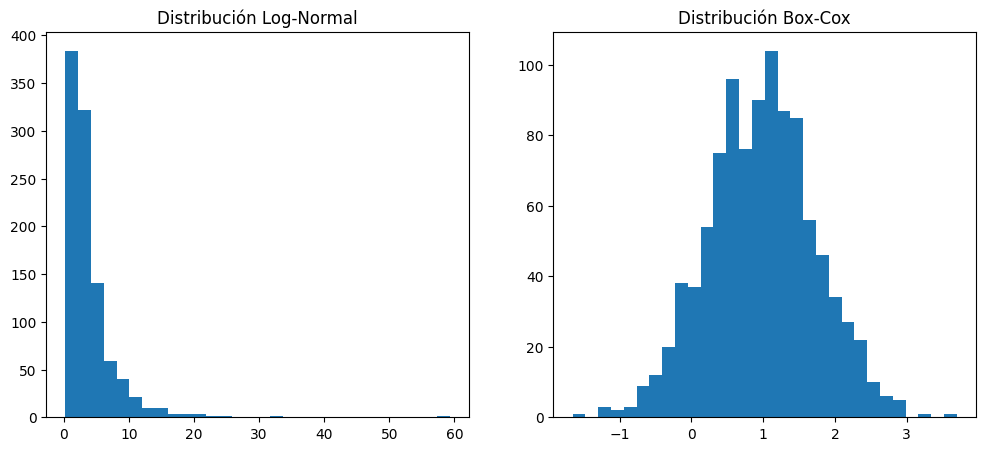

In [24]:
plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
plt.hist(data, bins=30)
plt.title("Distribución Log-Normal")

# Box-Cox
plt.subplot(1,2,2)
plt.hist(data_boxcox, bins=30)
plt.title("Distribución Box-Cox")

plt.show()

### ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?

La transformación Box-Cox redujo significativamente la asimetría de la distribución original, logrando que los datos se ajusten a una distribución aproximadamente normal. Esto se evidencia en el aumento considerable del p-valor, pasando de un valor extremadamente bajo a uno cercano a 1.

### ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?

El valor lambda obtenido (-0.0489) es cercano a cero, lo que indica que la transformación aplicada es muy similar a una transformación logarítmica. Esto sugiere que los datos originales requerían una compresión fuerte de los valores grandes para aproximarse a la normalidad.

A lo largo de la práctica se observó que las transformaciones lineales como Min-Max y Z-Score no modifican la distribución de los datos, mientras que las transformaciones no lineales como log y raíz cuadrada pueden reducir la asimetría. Sin embargo, la transformación Box-Cox resultó ser la más efectiva, ya que permitió aproximar los datos a una distribución normal de manera óptima al ajustar automáticamente el tipo de transformación.